<a href="https://colab.research.google.com/github/JosseAguirre/Taller-Pr-ctico-3---GRUPO-5---ENTREGABLE-FINAL/blob/dev/Taller_Pr%C3%A1ctico_3_ENTREGABLE_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from IPython.display import display

# 1. Configuración de Arquitectura y Logging
def configurar_entorno_y_auditoria():
    carpetas = ['data/raw', 'data/processed', 'reports', 'logs']
    for carpeta in carpetas:
        Path(carpeta).mkdir(parents=True, exist_ok=True)

    # Configuración de Logging para auditoría del proceso
    fecha_log = datetime.now().strftime("%Y%m%d")
    logging.basicConfig(
        filename=f'logs/pipeline_ejecucion_{fecha_log}.log',
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s'
    )
    logging.info("--- INICIO DE EJECUCIÓN DEL PIPELINE ---")

    print("--- 1. INICIALIZACIÓN DEL ENTORNO ---")
    print("✅ Estructura de directorios creada (raw, processed, reports, logs).")
    print("✅ Sistema de Logging (auditoría en segundo plano) activado.")

configurar_entorno_y_auditoria()

--- 1. INICIALIZACIÓN DEL ENTORNO ---
✅ Estructura de directorios creada (raw, processed, reports, logs).
✅ Sistema de Logging (auditoría en segundo plano) activado.


In [ ]:
# 2. Lectura Resiliente y Manejo de Excepciones
def cargar_datos_seguros():
    try:
        print("\n--- 2. LECTURA DE FUENTES Y CONCATENACIÓN ---")
        dtypes_dict = {'id_entrega': str, 'id_estudiante': str}

        # Lectura controlada
        df_matriz = pd.read_csv('data/raw/entregas_campus_matriz.csv', dtype=dtypes_dict, encoding='utf-8')
        df_ext = pd.read_csv('data/raw/entregas_campus_extension.csv', dtype=dtypes_dict, encoding='utf-8')
        df_master = pd.read_excel('data/raw/estudiantes_master.xlsx', dtype={'id_estudiante': str}, engine='openpyxl')

        logging.info(f"Lecturas exitosas. Matriz: {len(df_matriz)}, Extensión: {len(df_ext)}, Maestro: {len(df_master)}")

        # Integración estructural (Concatenación)
        df_matriz['campus_origen'] = 'Matriz'
        df_ext['campus_origen'] = 'Extensión'
        df_entregas_total = pd.concat([df_matriz, df_ext], ignore_index=True)

        print(f"✅ Archivos cargados exitosamente.")
        print(f"✅ Entregas consolidadas: {len(df_entregas_total)} registros.")
        print("\nVista previa de Entregas Unificadas (Capa Transaccional):")
        display(df_entregas_total.head(3))

        return df_entregas_total, df_master

    except FileNotFoundError as e:
        logging.error(f"Archivo no encontrado: {e}")
        print(f"❌ ERROR: {e}. Verifique la carpeta data/raw.")
        raise
    except Exception as e:
        logging.critical(f"Error inesperado: {e}")
        raise

df_entregas_total, df_master = cargar_datos_seguros()


--- 2. LECTURA DE FUENTES Y CONCATENACIÓN ---
✅ Archivos cargados exitosamente.
✅ Entregas consolidadas: 300 registros.

Vista previa de Entregas Unificadas (Capa Transaccional):


,id_entrega,id_estudiante,fecha_subida,materia,tipo_proyecto,puntaje_obtenido,estado_entrega,campus_origen
0,PRJ-1001,E001,2026-08-01,Sistemas de Bases de Datos,Modelado ER,95.5,Aprobado,Matriz
1,PRJ-1002,E002,2026-08-02,Desarrollo de Software,Prototipo,88.0,Aprobado,Matriz
2,PRJ-1003,E003,2026-08-03,DataOps,Pipeline,92.0,Aprobado,Matriz


In [ ]:
# 3. Integración Relacional y Pruebas Automatizadas
def integrar_y_testear(df_transaccional, df_maestro):
    print("\n--- 3. CRUCE RELACIONAL Y TESTING AUTOMATIZADO ---")

    df_consolidado = df_transaccional.merge(
        df_maestro,
        on='id_estudiante',
        how='left',
        validate='m:1',
        indicator=True
    )

    # Pruebas automatizadas de Calidad (Automated Testing)
    try:
        assert df_consolidado['id_entrega'].is_unique, "Fallo QA: IDs de entrega duplicados."
        assert len(df_consolidado) == len(df_transaccional), "Fallo QA: Variación volumétrica detectada."
        logging.info("Pruebas automatizadas de Unicidad y Volumetría superadas.")
        print("✅ Pruebas automatizadas (Unicidad y Volumetría) superadas con éxito.")
    except AssertionError as msg:
        logging.error(msg)
        print(f"❌ {msg}")
        raise

    # Extracción y muestra de huérfanos
    huerfanos = df_consolidado[df_consolidado['_merge'] == 'left_only']
    print(f"⚠️ Alerta Analítica: Se detectaron {len(huerfanos)} estudiantes huérfanos (Transacción sin matrícula).")
    print("\nVista previa de estudiantes huérfanos interceptados:")
    display(huerfanos.head(3))

    return df_consolidado

df_consolidado = integrar_y_testear(df_entregas_total, df_master)


--- 3. CRUCE RELACIONAL Y TESTING AUTOMATIZADO ---
✅ Pruebas automatizadas (Unicidad y Volumetría) superadas con éxito.
⚠️ Alerta Analítica: Se detectaron 5 estudiantes huérfanos (Transacción sin matrícula).

Vista previa de estudiantes huérfanos interceptados:


,id_entrega,id_estudiante,fecha_subida,materia,tipo_proyecto,puntaje_obtenido,estado_entrega,campus_origen_x,nombre_completo,fecha_nacimiento,carrera,campus_origen_y,tipo_beca,estado_academico,_merge
157,PRJ-2008,E999,2026-08-07,Desarrollo de Software,Frontend,100.0,Aprobado,Extensión,NaN,NaT,NaN,NaN,NaN,NaN,left_only
167,PRJ-2018,E888,2026-08-15,DataOps,Deploy,60.0,Revisión,Extensión,NaN,NaT,NaN,NaN,NaN,NaN,left_only
181,PRJ-2032,E777,2026-08-22,DataOps,Pipeline,NaN,Pendiente,Extensión,NaN,NaT,NaN,NaN,NaN,NaN,left_only


In [ ]:
# 4. Limpieza y Validación de Reglas de Negocio
def limpiar_y_validar_negocio(df: pd.DataFrame) -> pd.DataFrame:
    print("\n--- 4. LIMPIEZA Y VALIDACIÓN DE NEGOCIO ---")
    df_clean = df.copy()

    # Manejo de huérfanos (imputación responsable)
    cols_maestro = ['nombre_completo', 'carrera', 'campus_origen', 'tipo_beca', 'estado_academico']
    for col in cols_maestro:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna("No Registrado en Maestro")

    # Validación de Reglas de Negocio (Puntajes válidos)
    fuera_de_rango = ~df_clean['puntaje_obtenido'].between(0, 100) & df_clean['puntaje_obtenido'].notna()
    num_invalidos = fuera_de_rango.sum()

    if num_invalidos > 0:
        logging.warning(f"Se detectaron {num_invalidos} puntajes fuera del rango (0-100). Convertidos a NaN.")
        print(f"⚠️ Se detectaron y neutralizaron {num_invalidos} puntajes ilógicos (fuera de rango 0-100).")
        df_clean.loc[fuera_de_rango, 'puntaje_obtenido'] = np.nan

    print("✅ Reglas de negocio y limpieza aplicadas exitosamente.")
    print("\nVista previa del Dataset validado:")
    display(df_clean[['id_entrega', 'id_estudiante', 'puntaje_obtenido', 'nombre_completo', 'estado_academico']].head(5))

    return df_clean

df_final = limpiar_y_validar_negocio(df_consolidado)


--- 4. LIMPIEZA Y VALIDACIÓN DE NEGOCIO ---
✅ Reglas de negocio y limpieza aplicadas exitosamente.

Vista previa del Dataset validado:


,id_entrega,id_estudiante,puntaje_obtenido,nombre_completo,estado_academico
0,PRJ-1001,E001,95.5,Mateo Alvarado,Activo
1,PRJ-1002,E002,88.0,Camila Sánchez,Activo
2,PRJ-1003,E003,92.0,Santiago Ráos,Activo
3,PRJ-1004,E006,100.0,Martina Vega,Activo
4,PRJ-1005,E001,85.0,Mateo Alvarado,Activo



--- 5. DASHBOARD DE AUDITORÍA Y EXPORTACIÓN ---


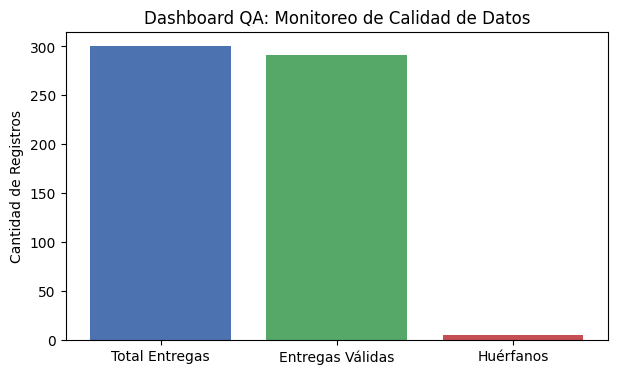


🚀 Pipeline productivo finalizado. Bóveda exportada exitosamente a Parquet en: data/processed/entregas_consolidadas_productivo.parquet
📊 Revise la carpeta logs/ y reports/ para consultar el historial persistente.


In [ ]:
# 5. Visualización Ejecutiva y Salida a Parquet
def generar_reporte_y_exportar(df: pd.DataFrame):
    print("\n--- 5. DASHBOARD DE AUDITORÍA Y EXPORTACIÓN ---")

    # Cálculo de métricas
    total = len(df)
    huerfanos = (df['_merge'] == 'left_only').sum()
    validos = df['puntaje_obtenido'].notna().sum()

    # Generación de Gráfico Ejecutivo
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(['Total Entregas', 'Entregas Válidas', 'Huérfanos'], [total, validos, huerfanos], color=['#4C72B0', '#55A868', '#C44E52'])
    ax.set_title('Dashboard QA: Monitoreo de Calidad de Datos', fontsize=12)
    ax.set_ylabel('Cantidad de Registros')

    # Guardar y mostrar
    Path('reports/calidad_datos_ejecutiva.png').parent.mkdir(exist_ok=True)
    plt.savefig('reports/calidad_datos_ejecutiva.png')
    plt.show()  # Muestra el gráfico en Google Colab

    # Limpieza final de columnas de auditoría y exportación
    df_export = df.drop(columns=['_merge'], errors='ignore')
    ruta_salida = Path("data/processed/entregas_consolidadas_productivo.parquet")

    # Exportación robusta a Parquet
    df_export.to_parquet(ruta_salida, engine='pyarrow', index=False)

    logging.info(f"Exportación Parquet exitosa: {ruta_salida}")
    print(f"\n🚀 Pipeline productivo finalizado. Bóveda exportada exitosamente a Parquet en: {ruta_salida}")
    print(f"📊 Revise la carpeta logs/ y reports/ para consultar el historial persistente.")

generar_reporte_y_exportar(df_final)